## 1. Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import pickle
from sklearn.model_selection import train_test_split, cross_val_score
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

## 2. Load Dataset and Understanding

In [2]:
df = pd.read_csv(r"C:\Users\arman\OneDrive\Desktop\Financial Fraud Detection System\Data\finance_fraud_dataset.csv")
df.head()

,transaction_id,customer_id,customer_age,customer_gender,income_group,bank_name,card_type,transaction_amount,transaction_type,transaction_time,transaction_location,state,device_type,operating_system,merchant_category,previous_transactions_count,account_balance,international_transaction,failed_login_attempts,suspicious_ip_flag,new_device_login,risk_score,is_fraud
0,TXN0000001,CUST402537,49,Male,Upper-Middle,Bandhan Bank,Visa,5085.46,Debit Card,10/25/2025,Nagpur,Gujarat,desktop,Android,Fuel,91,1155988.45,0,8,0,0,15,0
1,TXN0000002,CUST590435,37,Male,Low,HSBC India,RuPay,5918.67,Credit Card,7/7/2025,Agra,Uttar Pradesh,POS,Linux,Healthcare,61,637335.71,0,5,0,0,0,0
2,TXN0000003,CUST488921,63,Female,Low,PNB,RuPay,202.21,IMPS,7/27/2025,Delhi,Delhi,POS,iOS,Entertainment,1,103279.87,0,6,0,0,25,0
3,TXN0000004,CUST289957,62,Male,Low,ICICI,Visa,1317.15,Credit Card,3/19/2025,Chandigarh,Jammu & Kashmir,POS,Android,Insurance,145,1162845.82,0,5,0,1,15,0
4,TXN0000005,CUST568164,26,Male,Middle,Canara Bank,MasterCard,8092.44,ATM Withdrawal,8/24/2025,Prayagraj,Karnataka,mobile,Windows,Fuel,45,90952.53,1,10,0,1,50,1


In [3]:
df.shape

(10000, 23)

In [4]:
df.isnull().sum()

transaction_id                 0
customer_id                    0
customer_age                   0
customer_gender                0
income_group                   0
bank_name                      0
card_type                      0
transaction_amount             0
transaction_type               0
transaction_time               0
transaction_location           0
state                          0
device_type                    0
operating_system               0
merchant_category              0
previous_transactions_count    0
account_balance                0
international_transaction      0
failed_login_attempts          0
suspicious_ip_flag             0
new_device_login               0
risk_score                     0
is_fraud                       0
dtype: int64

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_id               10000 non-null  str    
 1   customer_id                  10000 non-null  str    
 2   customer_age                 10000 non-null  int64  
 3   customer_gender              10000 non-null  str    
 4   income_group                 10000 non-null  str    
 5   bank_name                    10000 non-null  str    
 6   card_type                    10000 non-null  str    
 7   transaction_amount           10000 non-null  float64
 8   transaction_type             10000 non-null  str    
 9   transaction_time             10000 non-null  str    
 10  transaction_location         10000 non-null  str    
 11  state                        10000 non-null  str    
 12  device_type                  10000 non-null  str    
 13  operating_system            

In [6]:
# Convert to Datetime
df['transaction_time'] = pd.to_datetime(df['transaction_time'])

In [7]:
df['year'] = df['transaction_time'].dt.year
df['month'] = df['transaction_time'].dt.month
df['day'] = df['transaction_time'].dt.day

In [8]:
df.drop('transaction_time', axis=1, inplace=True)

In [9]:
# Remove duplicates if exists.

print("Before:", df.shape)

df = df.drop_duplicates()

print("After:", df.shape)

Before: (10000, 25)
After: (10000, 25)


In [10]:
# Drop unwanted columns.
df = df.drop(["transaction_id", "customer_id", "risk_score", "suspicious_ip_flag"], axis=1)

In [11]:
# Categorical Columns.
cat_cols = [col for col in df.columns if df[col].dtype=='str']
cat_cols

['customer_gender',
 'income_group',
 'bank_name',
 'card_type',
 'transaction_type',
 'transaction_location',
 'state',
 'device_type',
 'operating_system',
 'merchant_category']

In [12]:
# printing the unique values in all the categorical columns
for col in cat_cols:
    print(f"Unique values in {col}:")
    print(df[col].unique())
    print("-" * 50)

Unique values in customer_gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str
--------------------------------------------------
Unique values in income_group:
<StringArray>
['Upper-Middle', 'Low', 'Middle', 'High']
Length: 4, dtype: str
--------------------------------------------------
Unique values in bank_name:
<StringArray>
[     'Bandhan Bank',        'HSBC India',               'PNB',
             'ICICI',       'Canara Bank',         'Axis Bank',
    'Kotak Mahindra',       'Indian Bank', 'South Indian Bank',
        'Union Bank',          'IndusInd',          'Yes Bank',
  'AU Small Finance',        'IDFC First',              'HDFC',
          'UCO Bank',    'Bank of Baroda',      'Federal Bank',
          'RBL Bank',               'SBI']
Length: 20, dtype: str
--------------------------------------------------
Unique values in card_type:
<StringArray>
['Visa', 'RuPay', 'MasterCard']
Length: 3, dtype: str
--------------------------------------------------
Unique val

In [13]:
# checking the class distribution of target column
print(df["is_fraud"].value_counts())

is_fraud
0    9448
1     552
Name: count, dtype: int64


## Insights:

1. transaction_id and customer_id removed as it is not required for modelling.
2. No mmissing values in the dataset.
4. Class imbalance identified in the target Dataset imbalanced

## 3. Exploratory Data Analysis (EDA)

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_age,10000.0,43.940800,15.388540,18.00,30.000,44.00,5.700000e+01,70.00
transaction_amount,10000.0,7029.084348,7033.730395,1.97,2005.475,4888.34,9.688733e+03,75447.44
previous_transactions_count,10000.0,75.117000,43.722764,0.00,37.000,75.00,1.130000e+02,150.00
account_balance,10000.0,748599.069381,429103.979575,5183.81,377039.100,747253.46,1.117381e+06,1499999.45
international_transaction,10000.0,0.078100,0.268342,0.00,0.000,0.00,0.000000e+00,1.00
failed_login_attempts,10000.0,5.049700,3.165222,0.00,2.000,5.00,8.000000e+00,10.00
new_device_login,10000.0,0.151400,0.358456,0.00,0.000,0.00,0.000000e+00,1.00
is_fraud,10000.0,0.055200,0.228382,0.00,0.000,0.00,0.000000e+00,1.00
year,10000.0,2025.000000,0.000000,2025.00,2025.000,2025.00,2.025000e+03,2025.00
month,10000.0,6.552300,3.437913,1.00,4.000,7.00,1.000000e+01,12.00


**Numerical Features - Analysis**

Understand the distribution of the numerical features

In [15]:
def plot_histogram(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.histplot(df[column_name], kde=True)
  plt.title(f"Distribution of {column_name}")

  # calculate the mean and median values for the columns
  col_mean = df[column_name].mean()
  col_median = df[column_name].median()

  # add vertical lines for mean and median
  plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
  plt.axvline(col_median, color="green", linestyle="-", label="Median")

  plt.legend()

  plt.show()

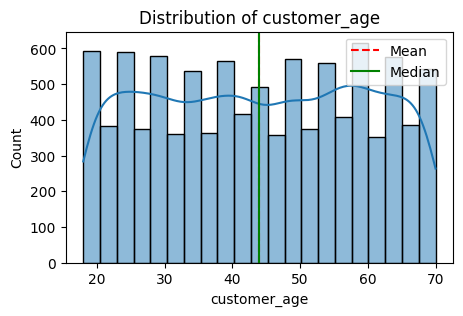

In [16]:
plot_histogram(df, "customer_age")

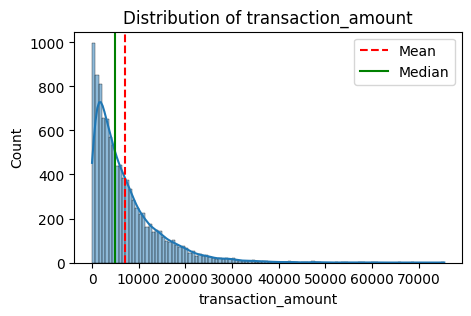

In [17]:
plot_histogram(df, "transaction_amount")

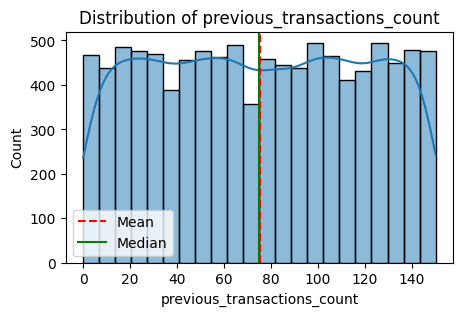

In [18]:
plot_histogram(df, "previous_transactions_count")

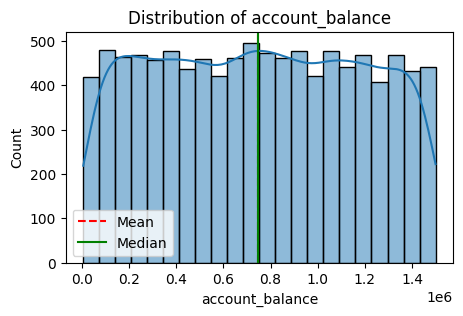

In [19]:
plot_histogram(df, "account_balance")

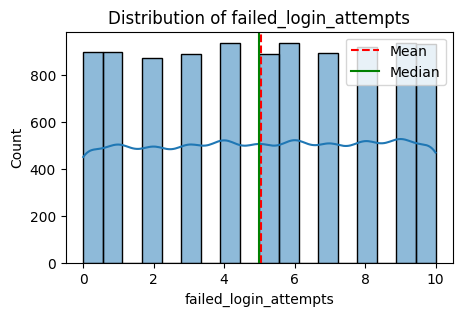

In [20]:
plot_histogram(df, "failed_login_attempts")

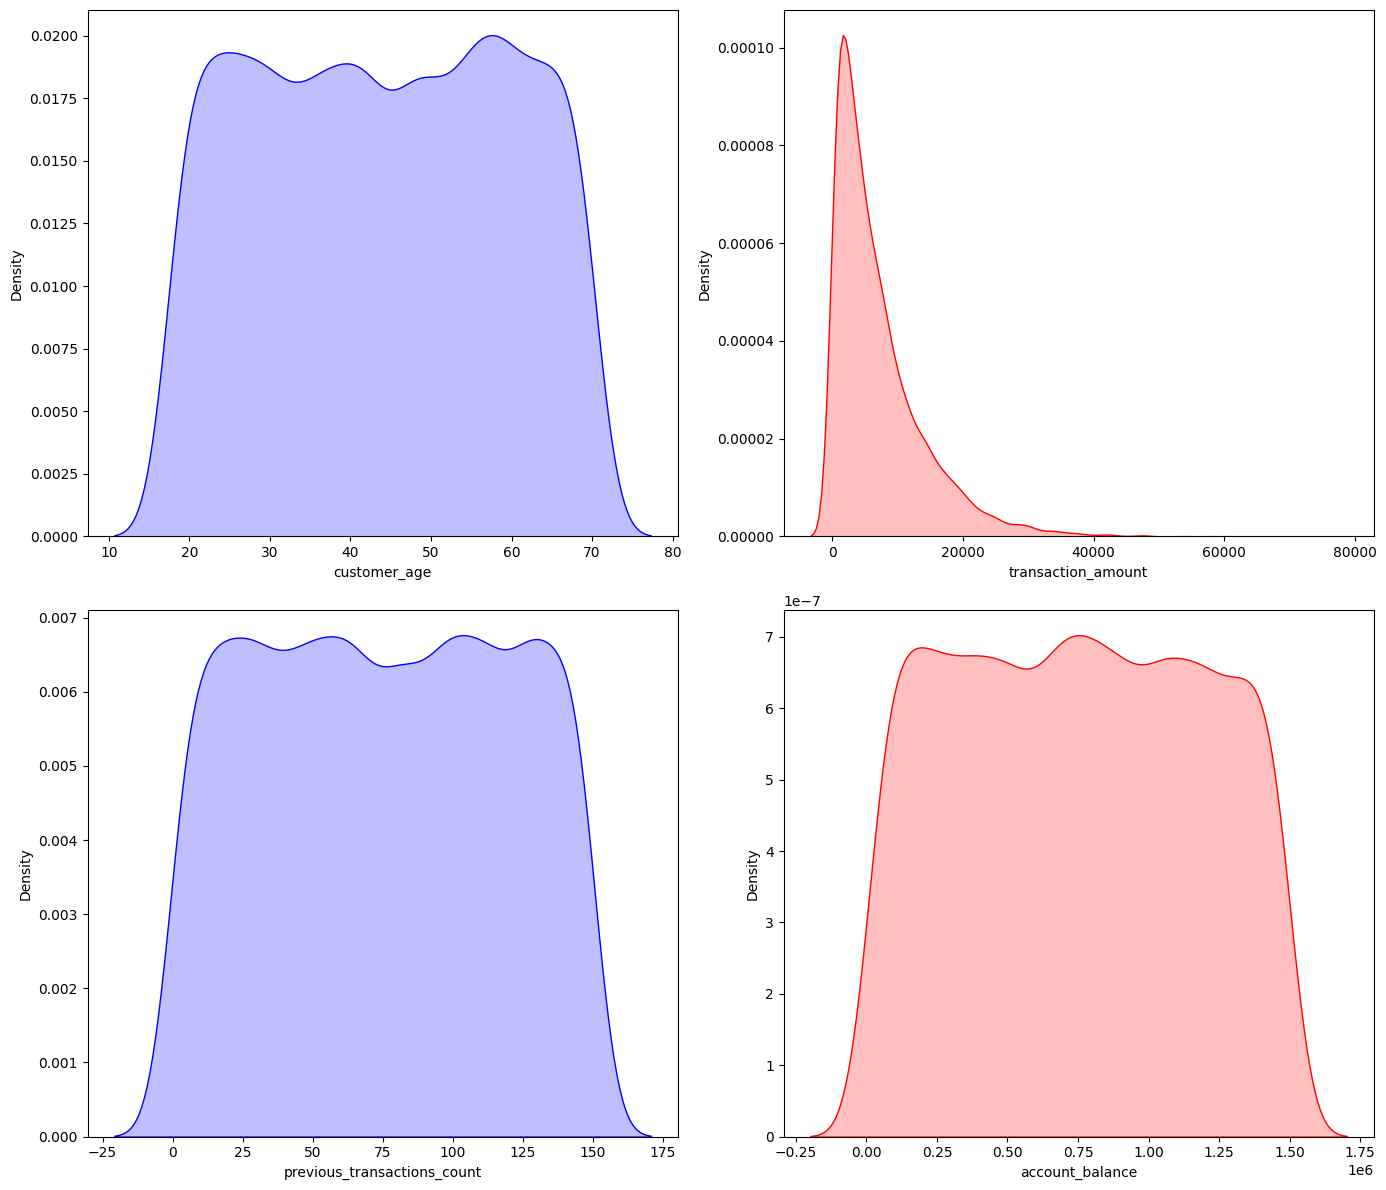

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
sns.kdeplot(data=df, x="customer_age", ax=axes[0,0], color='blue', fill=True)
sns.kdeplot(data=df, x="transaction_amount", ax=axes[0,1], color='red', fill=True)
sns.kdeplot(data=df, x="previous_transactions_count", ax=axes[1,0], color='blue', fill=True)
sns.kdeplot(data=df, x="account_balance", ax=axes[1,1], color='red', fill=True)
plt.tight_layout()
plt.show()

## Insights:

1. Customer ages are evenly distributed, indicating a balanced customer demographic.
2. Most transactions are low-value, while a few high-value transactions create a right-skewed distribution.
3. Customers have varying transaction histories, showing both new and active users in the dataset.
4. Account balances are widely distributed, representing customers from different financial backgrounds.
5. Higher failed login attempts may indicate suspicious or potentially fraudulent activity.
6. Most transactions fall under low-to-medium risk, while fewer transactions have very high risk scores.

**Box plot for numerical features**

In [22]:
def plot_boxplot(df, column_name):

  plt.figure(figsize=(5, 3))
  sns.boxplot(y=df[column_name])
  plt.title(f"Box Plot of {column_name}")
  plt.ylabel(column_name)
  plt.show

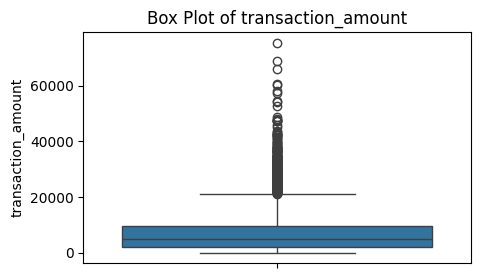

In [23]:
plot_boxplot(df, "transaction_amount")

**Correlation Heatmap for numerical columns**

<Axes: >

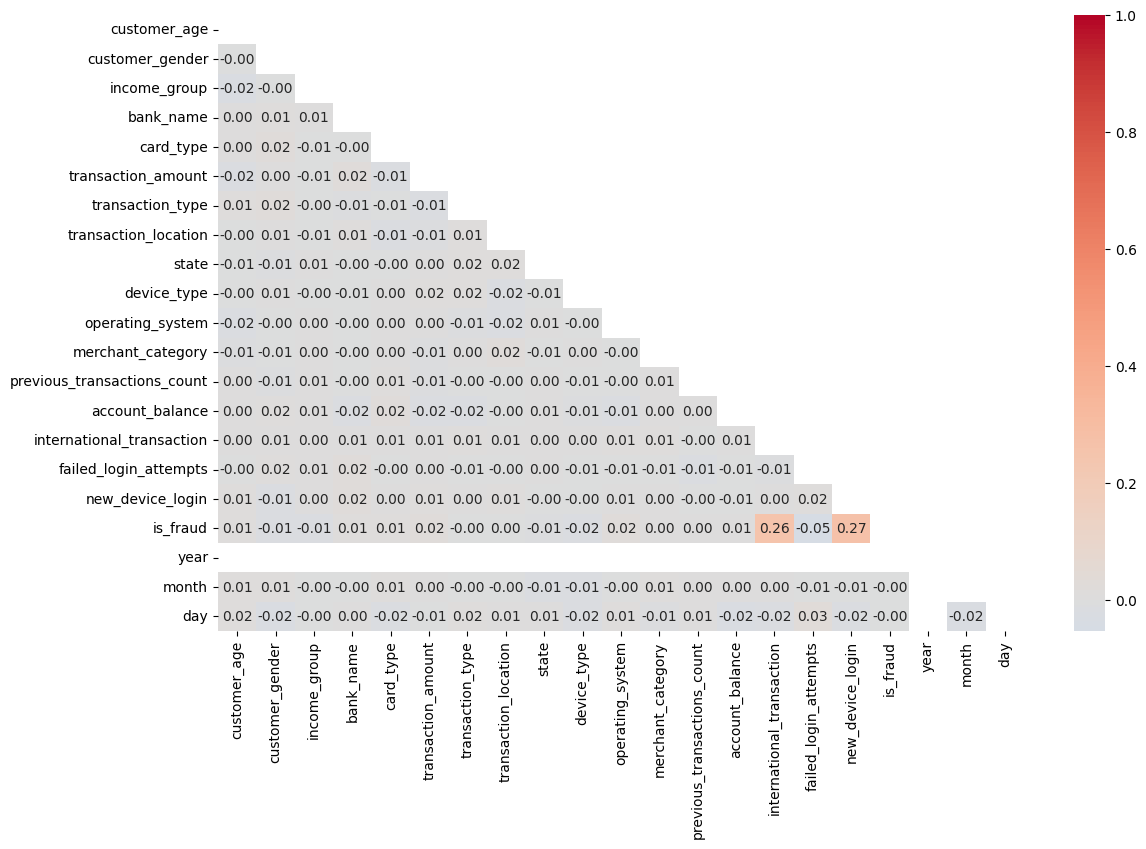

In [24]:
plt.figure(figsize=(13,8))
corr = df.apply(lambda x: pd.factorize(x)[0] if x.dtype!='float64' else x).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', vmax=1, center=0, annot=True, fmt='.2f')

**Categorical features - Analysis**

In [25]:
df['is_fraud'] = df['is_fraud'].map({0: 'No', 1: 'Yes'})

In [26]:
cat_cols

['customer_gender',
 'income_group',
 'bank_name',
 'card_type',
 'transaction_type',
 'transaction_location',
 'state',
 'device_type',
 'operating_system',
 'merchant_category']

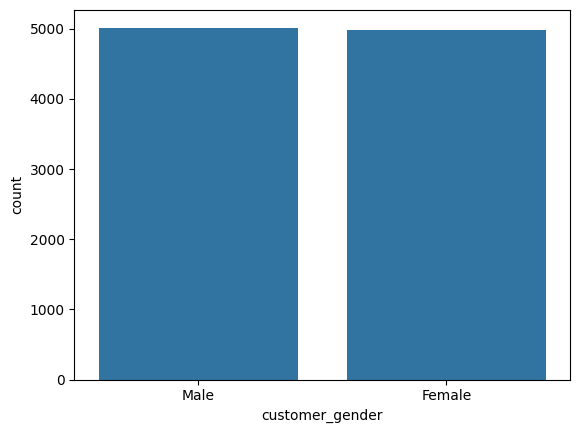

In [27]:
sns.countplot(x="customer_gender", data=df);

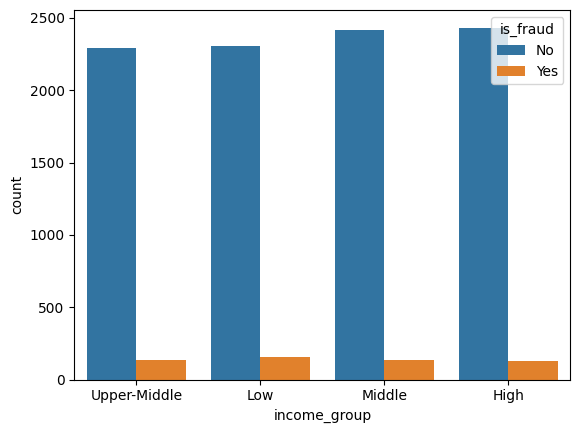

In [28]:
sns.countplot(x="income_group", hue="is_fraud", data=df);

## 4. Data Preprocessing

In [29]:
df.head()

,customer_age,customer_gender,income_group,bank_name,card_type,transaction_amount,transaction_type,transaction_location,state,device_type,operating_system,merchant_category,previous_transactions_count,account_balance,international_transaction,failed_login_attempts,new_device_login,is_fraud,year,month,day
0,49,Male,Upper-Middle,Bandhan Bank,Visa,5085.46,Debit Card,Nagpur,Gujarat,desktop,Android,Fuel,91,1155988.45,0,8,0,No,2025,10,25
1,37,Male,Low,HSBC India,RuPay,5918.67,Credit Card,Agra,Uttar Pradesh,POS,Linux,Healthcare,61,637335.71,0,5,0,No,2025,7,7
2,63,Female,Low,PNB,RuPay,202.21,IMPS,Delhi,Delhi,POS,iOS,Entertainment,1,103279.87,0,6,0,No,2025,7,27
3,62,Male,Low,ICICI,Visa,1317.15,Credit Card,Chandigarh,Jammu & Kashmir,POS,Android,Insurance,145,1162845.82,0,5,1,No,2025,3,19
4,26,Male,Middle,Canara Bank,MasterCard,8092.44,ATM Withdrawal,Prayagraj,Karnataka,mobile,Windows,Fuel,45,90952.53,1,10,1,Yes,2025,8,24


In [30]:
# Label encoding of target column
df["is_fraud"] = df["is_fraud"].map({"Yes": 1, "No": 0})

In [31]:
# initialize a dictionary to save the encoders
encoders = {}

# apply label encoding and store the encoders
for col in cat_cols:
  label_encoder = LabelEncoder()
  df[col] = label_encoder.fit_transform(df[col])
  encoders[col] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)
    
encoders

{'customer_gender': LabelEncoder(),
 'income_group': LabelEncoder(),
 'bank_name': LabelEncoder(),
 'card_type': LabelEncoder(),
 'transaction_type': LabelEncoder(),
 'transaction_location': LabelEncoder(),
 'state': LabelEncoder(),
 'device_type': LabelEncoder(),
 'operating_system': LabelEncoder(),
 'merchant_category': LabelEncoder()}

In [32]:
df.head()

,customer_age,customer_gender,income_group,bank_name,card_type,transaction_amount,transaction_type,transaction_location,state,device_type,operating_system,merchant_category,previous_transactions_count,account_balance,international_transaction,failed_login_attempts,new_device_login,is_fraud,year,month,day
0,49,1,3,2,2,5085.46,2,32,4,2,0,5,91,1155988.45,0,8,0,0,2025,10,25
1,37,1,1,7,1,5918.67,1,0,17,1,1,6,61,637335.71,0,5,0,0,2025,7,7
2,63,0,1,13,1,202.21,3,13,2,1,3,3,1,103279.87,0,6,0,0,2025,7,27
3,62,1,1,8,2,1317.15,1,9,7,1,0,7,145,1162845.82,0,5,1,0,2025,3,19
4,26,1,2,4,0,8092.44,0,36,9,3,2,5,45,90952.53,1,10,1,1,2025,8,24


In [33]:
df["transaction_amount"] = np.log(df["transaction_amount"]+1)

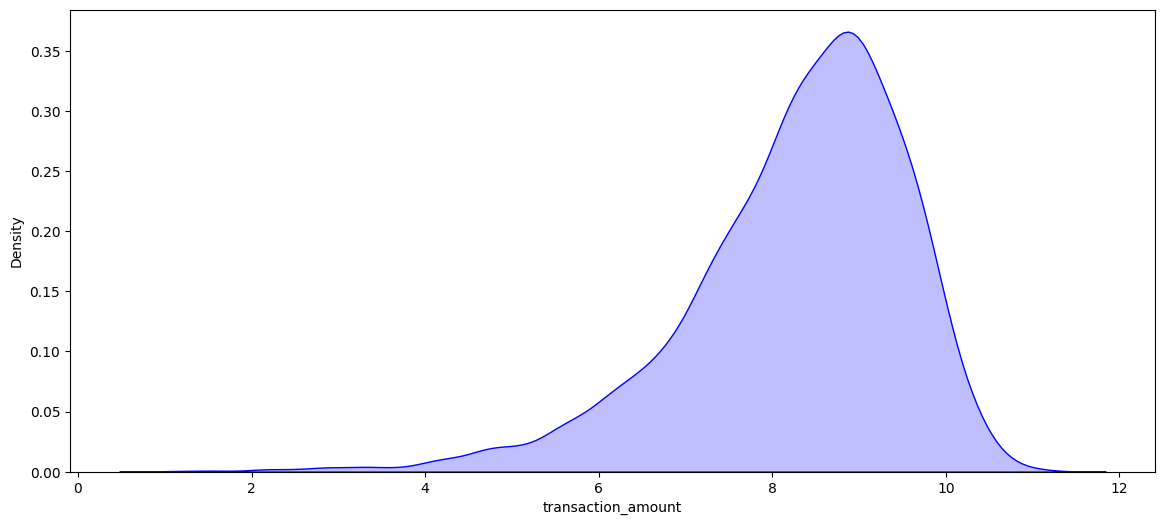

In [34]:
plt.figure(figsize=(14, 6))
sns.kdeplot(df["transaction_amount"], color='blue', shade=True);

**Traianing and test data split**

In [35]:
# splitting the features and target
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

In [36]:
# split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=52)

**Synthetic Minority Oversampling Technique (SMOTE)**

In [37]:
smote = SMOTE(random_state=42)

In [38]:
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [39]:
print(y_train_smote.shape)

(15130,)


In [40]:
print(y_train_smote.value_counts())

is_fraud
0    7565
1    7565
Name: count, dtype: int64


## 5. Model Training

**Training with default hyperparameters**

In [41]:
# dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [42]:
# dictionary to store the cross validation results
cv_scores = {}

# perform 5-fold cross validation for each model
for model_name, model in models.items():
  print(f"Training {model_name} with default parameters")
  scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
  cv_scores[model_name] = scores
  print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
  print("-"*70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.87
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.94
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.94
----------------------------------------------------------------------


In [43]:
cv_scores

{'Decision Tree': array([0.81097158, 0.88730998, 0.88268341, 0.88003966, 0.87475215]),
 'Random Forest': array([0.87640449, 0.95769993, 0.94910773, 0.93919365, 0.95538665]),
 'XGBoost': array([0.89325843, 0.96265697, 0.95274289, 0.94844679, 0.95836087])}

### XGBoost gives the highest accuracy 0.89 compared to other models with default parameters.

In [44]:
xgb = XGBClassifier(random_state=42)
xgb.fit(X_train_smote, y_train_smote)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [45]:
print(y_test.value_counts())

is_fraud
0    1883
1     117
Name: count, dtype: int64


## 6. Model Evaluation

In [46]:
# evaluate on test data
y_test_pred = xgb.predict(X_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.898
Confsuion Matrix:
 [[1762  121]
 [  83   34]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95      1883
           1       0.22      0.29      0.25       117

    accuracy                           0.90      2000
   macro avg       0.59      0.61      0.60      2000
weighted avg       0.91      0.90      0.90      2000



<Axes: >

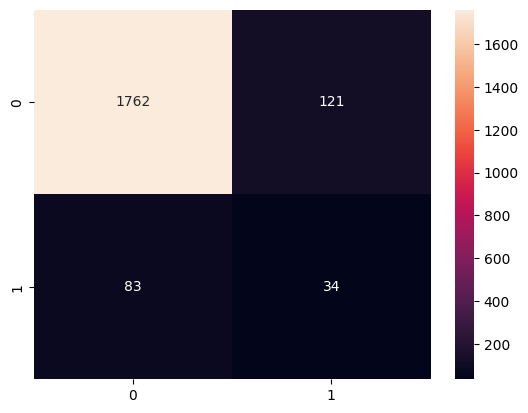

In [47]:
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d')

In [48]:
# save the trained model as a pickle file
model_data = {"model": xgb, "features_names": X.columns.tolist()}


with open("fraud_detection_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

## 7. Load the saved model and build a Predictive System

In [49]:
# load teh saved model and the feature names

with open("fraud_detection_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [50]:
print(loaded_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)


In [51]:
print(feature_names)

['customer_age', 'customer_gender', 'income_group', 'bank_name', 'card_type', 'transaction_amount', 'transaction_type', 'transaction_location', 'state', 'device_type', 'operating_system', 'merchant_category', 'previous_transactions_count', 'account_balance', 'international_transaction', 'failed_login_attempts', 'new_device_login', 'year', 'month', 'day']


In [52]:
df.head()

,customer_age,customer_gender,income_group,bank_name,card_type,transaction_amount,transaction_type,transaction_location,state,device_type,operating_system,merchant_category,previous_transactions_count,account_balance,international_transaction,failed_login_attempts,new_device_login,is_fraud,year,month,day
0,49,1,3,2,2,8.534337,2,32,4,2,0,5,91,1155988.45,0,8,0,0,2025,10,25
1,37,1,1,7,1,8.686036,1,0,17,1,1,6,61,637335.71,0,5,0,0,2025,7,7
2,63,0,1,13,1,5.314240,3,13,2,1,3,3,1,103279.87,0,6,0,0,2025,7,27
3,62,1,1,8,2,7.183985,1,9,7,1,0,7,145,1162845.82,0,5,1,0,2025,3,19
4,26,1,2,4,0,8.998809,0,36,9,3,2,5,45,90952.53,1,10,1,1,2025,8,24


In [53]:
input_data = {
    'customer_age': 49,
    'customer_gender': 'Male',
    'income_group': 'Upper-Middle',
    'bank_name': 'Bandhan Bank',
    'card_type': 'Visa',
    'transaction_amount': 5085.46,
    'transaction_type': 'Debit Card',
    'transaction_location': 'Nagpur',
    'state': 'Gujarat',
    'device_type': 'desktop',
    'operating_system': 'Android',
    'merchant_category': 'Fuel',
    'previous_transactions_count': 91,
    'account_balance': 1155988.45,
    'international_transaction': 0,
    'failed_login_attempts': 8,
    'new_device_login': 0,
    'year': 2025,
    'month': 10,
    'day': 25,
}

input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Fraud' if prediction[0] == 1 else 'No Fraud'}")
print(f"Prediciton Probability: {pred_prob}")

[0]
Prediction: No Fraud
Prediciton Probability: [[0.9675977  0.03240226]]


In [54]:
input_data = {
    'customer_age': 26,
    'customer_gender': 'Male',
    'income_group': 'Middle',
    'bank_name': 'Canara Bank',
    'card_type': 'MasterCard',
    'transaction_amount': 8092.44,
    'transaction_type': 'ATM Withdrawal',
    'transaction_location': 'Prayagraj',
    'state': 'Karnataka',
    'device_type': 'mobile',
    'operating_system': 'Windows',
    'merchant_category': 'Fuel',
    'previous_transactions_count': 45,
    'account_balance': 90952.53,
    'international_transaction': 1,
    'failed_login_attempts': 10,
    'new_device_login': 1,
    'year': 2025,
    'month': 8,
    'day': 24,
}

input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Fraud' if prediction[0] == 1 else 'No Fraud'}")
print(f"Prediciton Probability: {pred_prob}")

[1]
Prediction: Fraud
Prediciton Probability: [[0.07150388 0.9284961 ]]
